# Lab 18 — Satellite Links: Budgets, Orbits, Rain, ACM and the TWTA

**Companion to Chapter 23** (*Satellite Communications*).
**Time needed:** about 90 minutes. **Difficulty:** core.

A satellite link is the purest link budget in engineering: a transmitter 36 000 km (or 550 km) away, free
space in between, then a few kilometres of weather that decides whether you get your television tonight.
This lab is built on `commlib/satellite.py`, the module that drew every data figure in Chapter 23. You
will reproduce the chapter's worked examples, explore GEO versus LEO geometry and Doppler, compute rain
availability with the ITU-R P.618 procedure, simulate a year of rain to compare adaptive (ACM) with
constant (CCM) coding and modulation, and drive 16-QAM and 16-APSK through a saturated travelling-wave tube.

### What you will learn
1. Build an itemised downlink budget (EIRP, path loss, G/T, C/N0) and combine noise and interference terms.
2. Compute GEO look angles, and LEO pass geometry, delay and Doppler.
3. Predict rain attenuation statistics (ITU-R P.618) and the extra sky noise rain brings.
4. Quantify the throughput gain of DVB-S2 ACM over CCM across a synthetic rain year.
5. Measure the total degradation of 16-QAM and 16-APSK through a TWTA, and try a predistorter.

### Prerequisites
Lab 1 (sensitivity, noise), Lab 2 (constellations), Lab 5 (link budgets). Chapter 23.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The GEO Ku-band DTH link budget | yes |
| 2 | Pointing a dish: GEO look angles | |
| 3 | GEO versus LEO geometry; a LEO pass | yes |
| 4 | Rain: attenuation, sky noise and availability | |
| 5 | The Ka-band spot beam: ACM versus CCM over a rain year | |
| 6 | The TWTA: back-off, 16-QAM versus 16-APSK, predistortion | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import norm
import commlib as cl
from commlib import satellite as sat
from commlib import labkit as lk

rng = lk.setup(seed=18, lab="18")
KM = 1e3

Lab 18 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 18


## 1. The GEO Ku-band DTH link budget

The downlink carrier-to-noise-density ratio is a sum in decibels:

$$\frac{C}{N_0} = \mathrm{EIRP} - L_{fs} - L_{\text{misc}} + \frac{G}{T} - 10\log_{10}k\quad[\text{dB-Hz}],\qquad
\frac{C}{N} = \frac{C}{N_0} - 10\log_{10}R_s .$$

A bent-pipe link then adds the uplink noise and every noise-like interference term *as powers*:
$(C/(N+I))^{-1}_{\text{tot}} = \sum_i (C/X_i)^{-1}$. We rebuild Chapter 23's worked example: 51 dBW at the edge
of coverage, a viewer near Paris looking at 19.2°E, 11.7 GHz, a 60 cm dish and a 0.7 dB LNB, a 27.5 Mbaud
carrier, and uplink, adjacent-satellite, cross-polar and intermodulation terms of 25, 21, 22 and 20 dB.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

item,value
Satellite EIRP,+51.0 dBW
Free-space loss,-205.5 dB
"Gases, pointing, polarisation",-0.8 dB
Receive antenna gain,+35.5 dBi
System noise temperature,-19.3 dBK
Boltzmann's constant,+228.6
= C/N0,89.4 dB-Hz
− 10 log10(27.5 Mbaud),-74.4 dB
= downlink C/N,15.0 dB
"combined with uplink 25, ASI 21, XPOL 22, IM 20 dB",12.3 dB


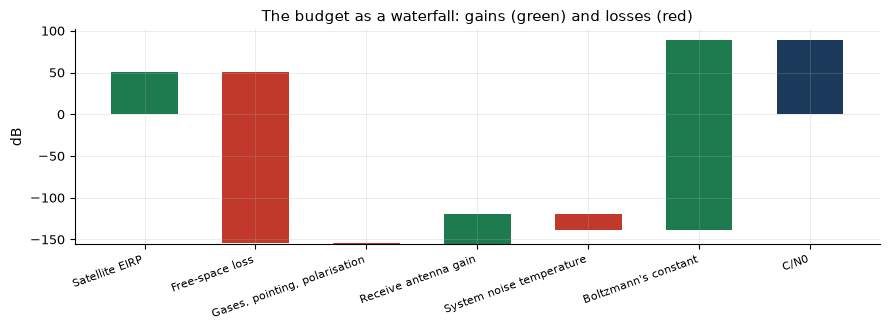

In [3]:
def dth_budget(eirp=51.0, dish_m=0.6, lnb_nf=0.7, t_ant=35.0, rs=27.5e6, misc=0.8, f=11.7e9,
               lat=48.0, lon=2.0, sat_lon=19.2, others=(25.0, 21.0, 22.0, 20.0)):
    az, el, d = sat.geo_look_angles(lat, lon, sat_lon)
    G = sat.dish_gain_dbi(dish_m, f, 0.65)
    tsys = sat.system_noise_temp(t_ant=t_ant, t_rx=sat.nf_to_temp(lnb_nf))
    lb = sat.LinkBudget("GEO Ku-band DTH downlink")
    lb.add("Satellite EIRP", eirp, "dBW").add("Free-space loss", -sat.fspl_db(d, f))
    lb.add("Gases, pointing, polarisation", -misc).add("Receive antenna gain", G, "dBi")
    lb.add("System noise temperature", -sat.db(tsys), "dBK").add("Boltzmann's constant", -sat.K_BOLTZ_DB, "")
    cn0 = lb.total()
    cn_down = cn0 - sat.db(rs)
    total = sat.combine_cn_db(cn_down, *others)
    return lb, dict(el=float(el), d=float(d), G=float(G), tsys=float(tsys), cn0=cn0, cn_down=float(cn_down),
                    total=float(total))

def dth_demo(eirp=51.0, dish_m=0.6, lnb_nf=0.7):
    lb, r = dth_budget(eirp, dish_m, lnb_nf)
    rows = [[n, f"{v:+.1f} {u}"] for n, v, u in lb.items]
    rows += [["= C/N0", f"{r['cn0']:.1f} dB-Hz"], ["− 10 log10(27.5 Mbaud)", f"{-sat.db(27.5e6):.1f} dB"],
             ["= downlink C/N", f"{r['cn_down']:.1f} dB"],
             ["combined with uplink 25, ASI 21, XPOL 22, IM 20 dB", f"{r['total']:.1f} dB"],
             ["margin over 8PSK 2/3 (6.62 dB)", f"{r['total'] - 6.62:.1f} dB"]]
    lk.table(rows, ["item", "value"], title=f"Elevation {r['el']:.1f}°, range {r['d'] / KM:,.0f} km, "
                                             f"G = {r['G']:.1f} dBi, Tsys = {r['tsys']:.0f} K")
    f, ax = lk.fig("wide")
    vals = [v for _, v, _ in lb.items]
    cum = np.r_[0, np.cumsum(vals)]
    names = [n for n, _, _ in lb.items]
    for i, v in enumerate(vals):
        ax.bar(i, v, bottom=cum[i], color=lk.GREEN if v > 0 else lk.RED, width=0.6)
    ax.bar(len(vals), cum[-1], color=lk.NAVY, width=0.6)
    ax.set_xticks(range(len(vals) + 1), names + ["C/N0"], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("dB"); ax.set_title("The budget as a waterfall: gains (green) and losses (red)")
    lk.show(f)

lk.interact(dth_demo, eirp=lk.slider(51, 40, 60, 0.5, "satellite EIRP (dBW)"),
            dish_m=lk.slider(0.6, 0.3, 1.8, 0.05, "dish diameter (m)"), lnb_nf=lk.slider(0.7, 0.3, 3.0, 0.1, "LNB NF (dB)"))

**What you should see.** $C/N_0$ ≈ 89.4 dB-Hz, downlink $C/N$ ≈ 15.0 dB and a combined 12.3 dB: the chapter's
numbers. The interference terms cost 2.7 dB, a third of the budget. Doubling the dish diameter adds 6 dB to the
downlink but much less to the total, because the interference terms do not improve.

### Try it yourself 1.1
Using `sat.combine_cn_db`, what total $C/(N+I)$ (dB) results if the downlink $C/N$ is 18 dB and the four other
terms stay at 25, 21, 22 and 20 dB?

In [5]:
answer_1_1 = None
lk.check("1.1 combined C/(N+I) with an 18 dB downlink", answer_1_1, float(sat.combine_cn_db(18, 25, 21, 22, 20)), atol=0.05)

[TODO] 1.1 combined C/(N+I) with an 18 dB downlink: not attempted yet: replace the None with your answer

## 2. Pointing a dish: GEO look angles

A geostationary satellite sits on the equator at a fixed longitude, 35 786 km up. From latitude $\varphi$ and
longitude difference $\Delta\lambda$, the central angle is $\cos\gamma = \cos\varphi\cos\Delta\lambda$, and the
elevation follows from the Earth-centre/station/satellite triangle. The map shows the elevation of 19.2°E across
Europe and Africa: below about 10° the path through the atmosphere (and the rain) becomes long.

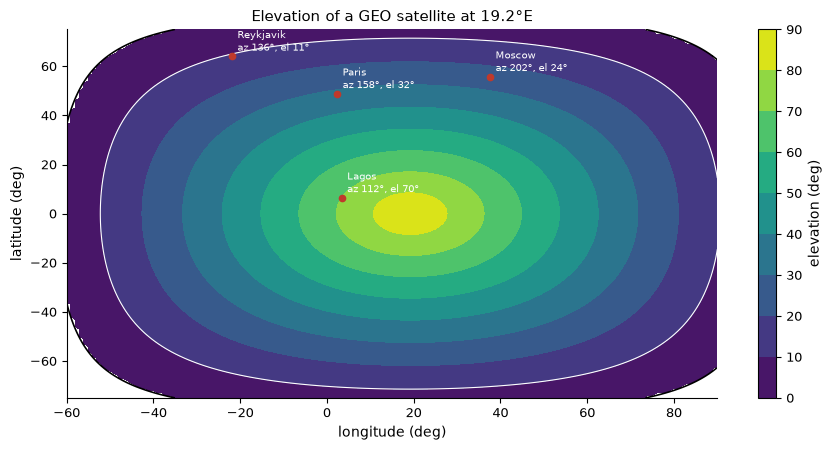

In [7]:
lats, lons = np.linspace(-75, 75, 151), np.linspace(-60, 90, 151)
LO, LA = np.meshgrid(lons, lats)
_, EL, _ = sat.geo_look_angles(LA, LO, 19.2)
f, ax = lk.fig((9, 4.6))
cs = ax.contourf(LO, LA, np.where(EL > 0, EL, np.nan), levels=np.arange(0, 91, 10), cmap="viridis")
ax.contour(LO, LA, EL, levels=[0, 10], colors=["k", "w"], linewidths=[1.2, 0.8])
for name, (la, lo) in {"Paris": (48.86, 2.35), "Lagos": (6.5, 3.4), "Reykjavik": (64.1, -21.9),
                       "Moscow": (55.8, 37.6)}.items():
    a_, e_, _ = sat.geo_look_angles(la, lo, 19.2)
    ax.plot(lo, la, "o", color=lk.RED); ax.annotate(f"{name}\naz {float(a_):.0f}°, el {float(e_):.0f}°", (lo, la),
                                                     xytext=(4, 4), textcoords="offset points", fontsize=7.5, color="white")
plt.colorbar(cs, ax=ax, label="elevation (deg)"); ax.grid(False)
ax.set_xlabel("longitude (deg)"); ax.set_ylabel("latitude (deg)"); ax.set_title("Elevation of a GEO satellite at 19.2°E")
lk.show(f)

### Try it yourself 2.1
What elevation (degrees) does a dish in Paris (48.86°N, 2.35°E) need for Astra at 19.2°E?

In [9]:
answer_2_1 = None
lk.check("2.1 elevation from Paris to 19.2°E", answer_2_1, float(sat.geo_look_angles(48.86, 2.35, 19.2)[1]), atol=0.3)

[TODO] 2.1 elevation from Paris to 19.2°E: not attempted yet: replace the None with your answer

## 3. GEO versus LEO geometry; a LEO pass

Altitude changes everything: slant range (path loss, delay), coverage area, pass duration and Doppler. A GEO
satellite is fixed in the sky at about 120 ms one-way delay (user to gateway via the satellite: ~240 ms) and zero
Doppler; a 550 km LEO satellite is a few milliseconds away, visible for a few minutes per pass, and its Doppler at
Ku band swings by about ±250 kHz.

### Interactive: altitude, frequency and pass geometry

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

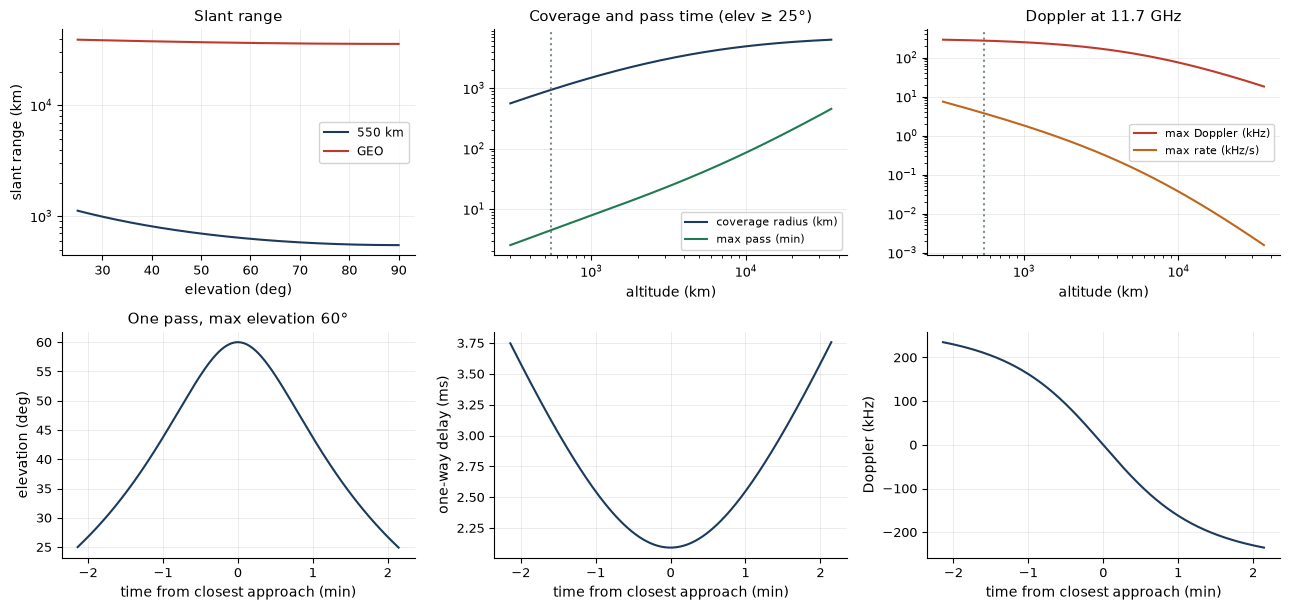

,value
orbital period,95.6 min
orbital speed,7.59 km/s
this pass: duration,4.3 min
this pass: max |Doppler|,235.3 kHz
this pass: max |Doppler rate|,3294 Hz/s


In [11]:
def geometry_demo(h_km=550.0, f_ghz=11.7, max_elev=60.0, min_elev=25.0):
    h = h_km * KM
    els = np.linspace(min_elev, 90, 200)
    f, axs = lk.fig((13, 6.2), 2, 3)
    ax = axs[0, 0]
    for hh, col, lab in [(h, lk.NAVY, f"{h_km:.0f} km"), (sat.GEO_ALT, lk.RED, "GEO")]:
        ax.plot(els, sat.slant_range(hh, els) / KM, color=col, label=lab)
    ax.set_yscale("log"); ax.set_xlabel("elevation (deg)"); ax.set_ylabel("slant range (km)"); ax.legend()
    ax.set_title("Slant range")
    ax = axs[0, 1]
    hs = np.logspace(np.log10(300e3), np.log10(sat.GEO_ALT), 200)
    ax.loglog(hs / KM, sat.coverage_radius(hs, min_elev) / KM, color=lk.NAVY, label="coverage radius (km)")
    ax.loglog(hs / KM, sat.max_pass_duration(hs, min_elev) / 60, color=lk.GREEN, label="max pass (min)")
    ax.axvline(h_km, color=lk.GRAY, ls=":"); ax.set_xlabel("altitude (km)"); ax.legend(fontsize=8)
    ax.set_title(f"Coverage and pass time (elev ≥ {min_elev:.0f}°)")
    ax = axs[0, 2]
    ax.loglog(hs / KM, sat.max_doppler(hs, f_ghz * 1e9) / KM, color=lk.RED, label="max Doppler (kHz)")
    ax.loglog(hs / KM, sat.max_doppler_rate(hs, f_ghz * 1e9) / KM, color=lk.ORANGE, label="max rate (kHz/s)")
    ax.axvline(h_km, color=lk.GRAY, ls=":"); ax.set_xlabel("altitude (km)"); ax.legend(fontsize=8)
    ax.set_title(f"Doppler at {f_ghz:.1f} GHz")
    p = sat.leo_pass(h, f_ghz * 1e9, max_elev, min_elev, 1.0)
    tm = p["t"] / 60
    for ax, y, yl in [(axs[1, 0], p["elev"], "elevation (deg)"), (axs[1, 1], p["delay"] * 1e3, "one-way delay (ms)"),
                      (axs[1, 2], p["doppler"] / KM, "Doppler (kHz)")]:
        ax.plot(tm, y, color=lk.NAVY); ax.set_xlabel("time from closest approach (min)"); ax.set_ylabel(yl)
    axs[1, 0].set_title(f"One pass, max elevation {max_elev:.0f}°")
    lk.show(f)
    lk.table([["orbital period", f"{sat.orbital_period(sat.R_E + h) / 60:.1f} min"],
              ["orbital speed", f"{sat.circular_speed(h) / KM:.2f} km/s"],
              ["this pass: duration", f"{(p['t'][-1] - p['t'][0]) / 60:.1f} min"],
              ["this pass: max |Doppler|", f"{np.max(np.abs(p['doppler'])) / KM:.1f} kHz"],
              ["this pass: max |Doppler rate|", f"{np.max(np.abs(p['doppler_rate'])):.0f} Hz/s"]], ["", "value"])

lk.interact(geometry_demo, h_km=lk.slider(550, 300, 36000, 50, "altitude (km)"), f_ghz=lk.slider(11.7, 1.5, 30, 0.1, "frequency (GHz)"),
            max_elev=lk.slider(60, 10, 90, 1, "pass max elevation (deg)"), min_elev=lk.slider(25, 0, 40, 1, "min elevation (deg)"))

**What you should see.** At 550 km the slant range at 25° is about 1100 km (vs 38 000+ km for GEO), a pass above 25°
lasts a few minutes, and the Doppler sweeps through zero at closest approach with its fastest rate there.
For a direct-to-cell system, set about 520 km and 1.9 GHz: the Doppler shrinks to tens of kHz, still far more than an
LTE/NR handset expects, which is why NTN (3GPP Release 17) pre-compensates Doppler and timing using GNSS and ephemeris.

### Try it yourself 3.1
What is the maximum Doppler shift (kHz) for a 550 km satellite at 2 GHz (`sat.max_doppler`)?

In [13]:
answer_3_1 = None
lk.check("3.1 max Doppler, 550 km, 2 GHz (kHz)", answer_3_1, float(sat.max_doppler(550e3, 2e9)) / 1e3, atol=0.2)

[TODO] 3.1 max Doppler, 550 km, 2 GHz (kHz): not attempted yet: replace the None with your answer

## 4. Rain: attenuation, sky noise and availability

Rain attenuates by $\gamma_R = kR^\alpha$ dB/km (ITU-R P.838) over an effective path through the rain layer;
ITU-R P.618 turns the 0.01%-of-the-year rain rate $R_{0.01}$ (from the P.837 maps) into the attenuation
exceeded for any percentage of the year. Rain also **emits**: a fade of $A$ dB adds
$\Delta T = T_m(1 - 10^{-A/10})$ (with $T_m \approx 275$ K) to the antenna temperature, so a downlink with a quiet
receiver loses more $C/N$ than the attenuation alone. We rebuild the chapter's DTH rain table
($R_{0.01}$ = 30 mm/h, typical of western Europe).

time exceeded,availability,rain loss (dB),Tsys (K),total C/(N+I) (dB),8PSK 2/3 OK?
clear sky,—,0.0,86,12.3,yes
1%,99%,0.5,114,11.3,yes
0.5%,99.5%,0.8,131,10.7,yes
0.1%,99.9%,2.1,192,8.5,yes
0.05%,99.95%,3.1,226,7.1,yes
0.01%,99.99%,6.6,301,2.8,no


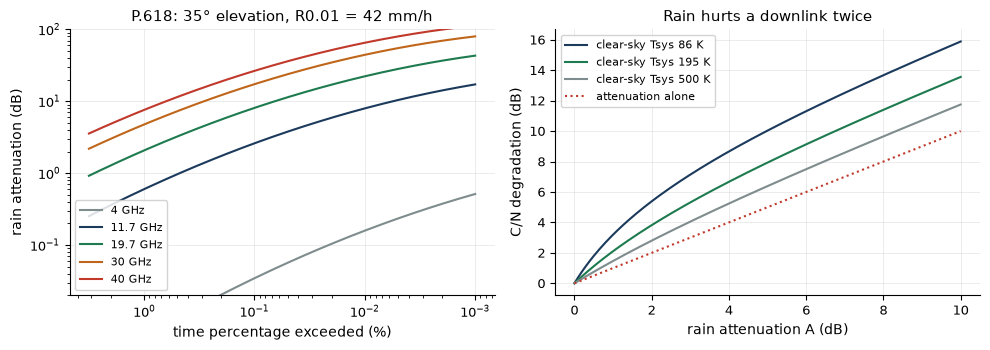

In [15]:
_, d0 = dth_budget()
ps = [1, 0.5, 0.1, 0.05, 0.01]
rows = [["clear sky", "—", 0.0, d0["tsys"], d0["total"], "yes"]]
for p_ in ps:
    A = float(sat.rain_atten_p618(11.7, d0["el"], p_, 30, lat_deg=48))
    T_ = 35 + sat.rain_noise_temp(A) + sat.nf_to_temp(0.7)
    cn_d = d0["cn_down"] - A - sat.db(T_ / d0["tsys"])
    tot = float(sat.combine_cn_db(cn_d, 25, 21, 22, 20))
    rows.append([f"{p_}%", f"{100 - p_}%", A, float(T_), tot, "yes" if tot >= 6.62 else "no"])
lk.table(rows, ["time exceeded", "availability", "rain loss (dB)", "Tsys (K)", "total C/(N+I) (dB)", "8PSK 2/3 OK?"],
         fmt={2: ".1f", 3: ".0f", 4: ".1f"}, title="Rain on the Ku-band DTH link (P.618, R0.01 = 30 mm/h)")
pp = np.logspace(-3, 0.5, 200)
f, ax = lk.fig("row2", 1, 2)
for fg, col in [(4, lk.GRAY), (11.7, lk.NAVY), (19.7, lk.GREEN), (30, lk.ORANGE), (40, lk.RED)]:
    ax[0].loglog(pp, sat.rain_atten_p618(fg, 35, pp, 42, lat_deg=45), color=col, label=f"{fg:g} GHz")
ax[0].invert_xaxis(); ax[0].set_xlabel("time percentage exceeded (%)"); ax[0].set_ylabel("rain attenuation (dB)")
ax[0].set_ylim(0.02, 100); ax[0].legend(fontsize=8); ax[0].set_title("P.618: 35° elevation, R0.01 = 42 mm/h")
A_ = np.linspace(0, 10, 200)
for t0, col in [(86, lk.NAVY), (195, lk.GREEN), (500, lk.GRAY)]:
    ax[1].plot(A_, A_ + sat.db((t0 + sat.rain_noise_temp(A_)) / t0), color=col, label=f"clear-sky Tsys {t0} K")
ax[1].plot(A_, A_, ":", color=lk.RED, label="attenuation alone")
ax[1].set_xlabel("rain attenuation A (dB)"); ax[1].set_ylabel("C/N degradation (dB)"); ax[1].legend(fontsize=8)
ax[1].set_title("Rain hurts a downlink twice")
lk.show(f)

**What you should see.** The table matches the chapter: the link holds 8PSK 2/3 for about 99.95% of the year. At 0.1%,
2.1 dB of attenuation costs more than 5 dB of $C/N$ because the sky noise more than doubles $T_{\text{sys}}$. On the
left, Ka band (19.7 GHz) fades are roughly three times deeper than Ku band (in dB) and Q band (40 GHz) is brutal.

## 5. The Ka-band spot beam: ACM versus CCM over a rain year

The chapter's second worked example: a high-throughput satellite spot beam at 19.7 GHz (58 dBW EIRP), a user at
40°N, 30° of longitude from the satellite, a 75 cm dish, a 200 Mbaud carrier, co-channel interference of 20 dB, and a
wet climate ($R_{0.01}$ = 42 mm/h). **CCM** must choose one MODCOD that closes 99.9% of the time; **ACM** picks the best
MODCOD frame by frame from the terminal's reported $E_s/N_0$ (`sat.acm_select`, DVB-S2 thresholds of ETSI EN 302 307-1).

To see it in time we synthesise a year of 1-minute rain attenuation: a correlated Gaussian process (AR(1), about
30-minute correlation time) mapped through the P.618 distribution, so the *statistics* are exactly P.618's and the
fades last realistically long.

time exceeded,rain loss (dB),C/(N+I) (dB),ACM MODCOD,b/s/Hz
clear sky,0.0,11.2,16APSK 3/4,2.97
5%,0.7,10.0,16APSK 2/3,2.64
1%,2.1,7.7,8PSK 2/3,1.98
0.5%,3.3,6.1,8PSK 3/5,1.78
0.1%,8.2,0.4,QPSK 2/5,0.79
0.05%,11.5,-3.1,outage,0.00


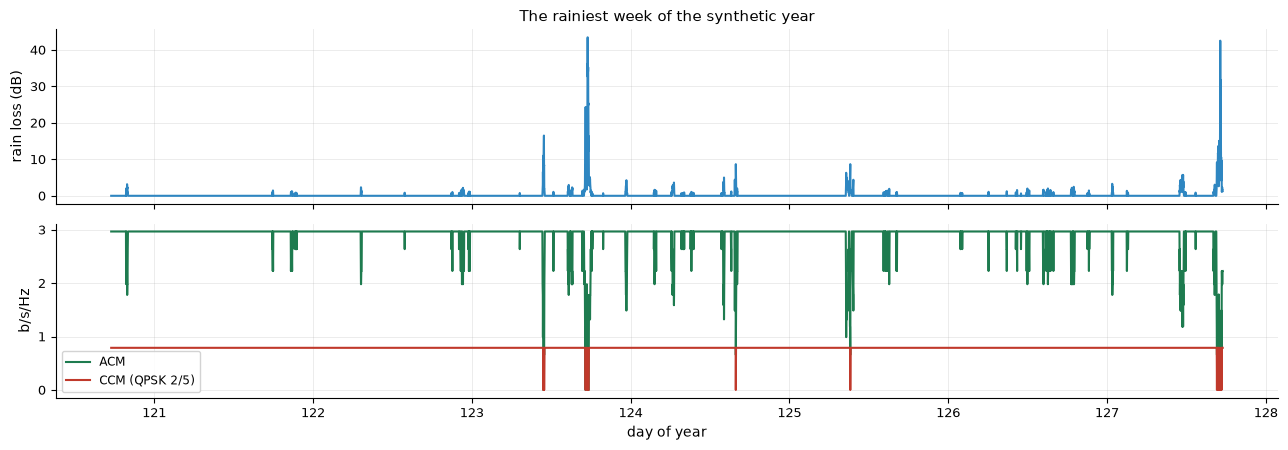

scheme,mean b/s/Hz,availability (%)
ACM,2.93,99.931
CCM QPSK 2/5,0.79,99.894
ACM / CCM throughput,3.72,


In [18]:
f_ka, eirp_ka, rs_ka, cci = 19.7e9, 58.0, 200e6, 20.0
_, el_ka, d_ka = sat.geo_look_angles(40.0, 0.0, 30.0)
G_ka = float(sat.dish_gain_dbi(0.75, f_ka, 0.65))
T_rx = sat.nf_to_temp(1.5)
def ka_cnt(A):
    """Total C/(N+I) (dB) for rain attenuation A (dB): fade + sky noise + co-channel interference."""
    tsys = sat.system_noise_temp(60.0 + sat.rain_noise_temp(A), T_rx, loss_db=0.3)
    cn0 = eirp_ka - sat.fspl_db(d_ka, f_ka) - 0.8 - A + G_ka - sat.db(tsys) - sat.K_BOLTZ_DB
    cn = np.asarray(cn0 - sat.db(rs_ka), float)
    return sat.combine_cn_db(cn, np.full_like(cn, cci))        # broadcast the fixed C/I term

rows = []
for p_ in [None, 5, 1, 0.5, 0.1, 0.05]:
    A = 0.0 if p_ is None else float(sat.rain_atten_p618(19.7, float(el_ka), p_, 42, lat_deg=40))
    c = float(ka_cnt(A))
    m = sat.acm_select(c, 0.5)
    rows.append(["clear sky" if p_ is None else f"{p_}%", A, c, m[0] if m else "outage", m[1] if m else 0.0])
lk.table(rows, ["time exceeded", "rain loss (dB)", "C/(N+I) (dB)", "ACM MODCOD", "b/s/Hz"], fmt={1: ".1f", 2: ".1f", 4: ".2f"},
         title=f"Ka-band spot beam: elevation {float(el_ka):.1f}°, range {float(d_ka) / KM:,.0f} km, G = {G_ka:.1f} dBi")

# --- a synthetic year of rain ----------------------------------------------------------------
n_min = 365 * 24 * 60
tau_min = 30.0
a_ar = np.exp(-1 / tau_min)
x = lfilter([np.sqrt(1 - a_ar ** 2)], [1, -a_ar], rng.standard_normal(n_min))     # unit-variance AR(1)
p_exceed = 100 * norm.sf(x)                                                       # percent of time exceeded
A_year = np.where(p_exceed < 5, sat.rain_atten_p618(19.7, float(el_ka), np.clip(p_exceed, 1e-3, 5), 42, lat_deg=40), 0.0)
cnt_year = ka_cnt(A_year)
mods = sat.DVBS2_MODCODS
thr = np.array([m[2] for m in mods]); eta = np.array([m[1] for m in mods])
ok = thr[None, :] + 0.5 <= cnt_year[:, None]
eff_acm = np.where(ok.any(1), np.max(np.where(ok, eta[None, :], 0), axis=1), 0.0)
ccm = sat.acm_select(float(ka_cnt(float(sat.rain_atten_p618(19.7, float(el_ka), 0.1, 42, lat_deg=40)))), 0.5)
eff_ccm = np.where(cnt_year >= ccm[2] + 0.5, ccm[1], 0.0)
f, ax = lk.fig((13, 4.6), 2, 1, sharex=True)
wk = slice(int(np.argmax(A_year)) - 3 * 1440, int(np.argmax(A_year)) + 4 * 1440)       # the rainiest week
tdays = np.arange(n_min)[wk] / 1440
ax[0].plot(tdays, A_year[wk], color=lk.BLUE); ax[0].set_ylabel("rain loss (dB)")
ax[0].set_title("The rainiest week of the synthetic year")
ax[1].plot(tdays, eff_acm[wk], color=lk.GREEN, label="ACM"); ax[1].plot(tdays, eff_ccm[wk], color=lk.RED, label=f"CCM ({ccm[0]})")
ax[1].set_ylabel("b/s/Hz"); ax[1].set_xlabel("day of year"); ax[1].legend(loc="lower left")
lk.show(f)
lk.table([["ACM", eff_acm.mean(), 100 * np.mean(eff_acm > 0)], [f"CCM {ccm[0]}", eff_ccm.mean(), 100 * np.mean(eff_ccm > 0)],
          ["ACM / CCM throughput", eff_acm.mean() / eff_ccm.mean(), ""]],
         ["scheme", "mean b/s/Hz", "availability (%)"], fmt={1: ".2f", 2: ".3f"})

**What you should see.** The table reproduces Chapter 23: 16APSK 3/4 in clear sky, stepping down through 8PSK to
QPSK 2/5 at 0.1%, and an outage below about 0.05%. Over the year, ACM averages close to 2.9 b/s/Hz against the CCM
design's 0.79: about 3.7 times the throughput at the same availability. In the rainy week you can watch ACM
shed efficiency only while a storm passes, where CCM wastes the clear sky all year round.

## 6. The TWTA: back-off, 16-QAM versus 16-APSK, predistortion

A satellite's travelling-wave tube amplifier is most efficient at saturation, where it compresses amplitude
(AM/AM) and rotates phase (AM/PM, Saleh's model). Backing off the input (IBO) linearises it but wastes output power
(OBO). The figure of merit is the **total degradation** $\mathrm{TD} = \mathrm{OBO} + \Delta(E_s/N_0)$: the output
back-off plus the extra SNR the receiver needs to reach the same error rate with the distortion. Its minimum is the
best operating point. 16-APSK, with only two rings, survives compression far better than 16-QAM's three amplitude
levels. A **predistorter** applies the inverse of the AM/AM and AM/PM curves before the tube.

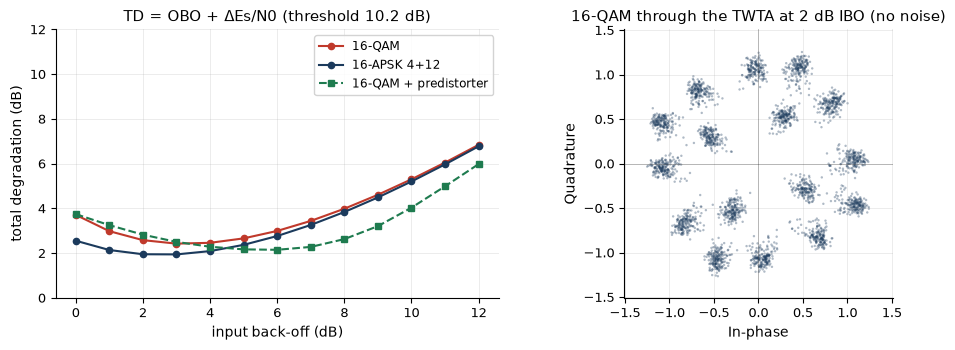

In [21]:
def predistort(x, ibo_db):
    """Ideal Saleh-inverse predistorter (amplitudes beyond saturation are clipped to saturation)."""
    p = sat.SALEH_TWTA
    r_sat = 1 / np.sqrt(p["ba"])
    a_sat = p["aa"] * r_sat / (1 + p["ba"] * r_sat ** 2)
    xs = x / np.sqrt(np.mean(np.abs(x) ** 2)) * r_sat * 10 ** (-ibo_db / 20)      # same scaling as saleh_twta
    a_des = np.minimum(np.abs(xs) * p["aa"], a_sat * 0.999)                       # target: linear gain aa
    # invert A(r) = aa r / (1 + ba r^2) on the branch below saturation
    r = (p["aa"] - np.sqrt(np.maximum(p["aa"] ** 2 - 4 * p["ba"] * a_des ** 2, 0))) / (2 * p["ba"] * np.maximum(a_des, 1e-12))
    _, P = sat.saleh_am_am_pm(r)
    return r * np.exp(1j * (np.angle(xs) - P))

def total_degradation(pts, thr_db, ibos, pd=False, N=8000, sps=4):
    taps = cl.rrc_taps(0.2, sps, 10)
    s = pts[rng.integers(0, len(pts), N)]
    x = cl.shape(s, taps, sps)
    out = []
    for ibo in ibos:
        if pd:
            xin = predistort(x, ibo)
            y = sat.saleh_twta(xin, ibo_db=-sat.db(np.mean(np.abs(xin) ** 2) / (1 / sat.SALEH_TWTA["ba"])))
        else:
            y = sat.saleh_twta(x, ibo)
        obo = -sat.db(np.mean(np.abs(y) ** 2))
        z = cl.matched_filter(y, taps)[len(taps) - 1::sps][:N][50:-50]
        ss = s[50:-50]
        g = np.vdot(ss, z) / np.vdot(ss, ss)
        mer = np.abs(g) ** 2 * np.mean(np.abs(ss) ** 2) / np.mean(np.abs(z - g * ss) ** 2)
        req = 1 / (1 / lk.undb(thr_db) - 1 / mer) if mer > lk.undb(thr_db) else np.inf
        out.append(obo + sat.db(req / lk.undb(thr_db)))
    return np.array(out)

qam16 = cl.get_constellation("16qam").points
apsk16 = sat.dvbs2_16apsk("3/4")
ibos = np.arange(0, 12.1, 1.0)
f, ax = lk.fig("row2", 1, 2)
for pts, name, col in [(qam16, "16-QAM", lk.RED), (apsk16, "16-APSK 4+12", lk.NAVY)]:
    ax[0].plot(ibos, total_degradation(pts, 10.21, ibos), "o-", color=col, label=name)
ax[0].plot(ibos, total_degradation(qam16, 10.21, ibos, pd=True), "s--", color=lk.GREEN, label="16-QAM + predistorter")
ax[0].set_xlabel("input back-off (dB)"); ax[0].set_ylabel("total degradation (dB)"); ax[0].set_ylim(0, 12)
ax[0].legend(); ax[0].set_title("TD = OBO + ΔEs/N0 (threshold 10.2 dB)")
xq = cl.shape(qam16[rng.integers(0, 16, 3000)], cl.rrc_taps(0.2, 4, 10), 4)
yq = sat.saleh_twta(xq, 2.0)
zq = cl.matched_filter(yq, cl.rrc_taps(0.2, 4, 10))[cl.rrc_taps(0.2, 4, 10).size - 1::4]
zq = zq / np.sqrt(np.mean(np.abs(zq) ** 2))
lk.constellation(ax[1], zq[50:-50], None, "16-QAM through the TWTA at 2 dB IBO (no noise)")
lk.show(f)

**What you should see.** Each curve is a bowl: at large back-off TD equals OBO (the tube is wasted), near saturation the
distortion explodes. 16-APSK's minimum is lower and occurs closer to saturation than 16-QAM's, which is exactly why DVB-S2
chose APSK. The ideal predistorter lowers 16-QAM's best TD a little (its bowl is flatter and shifted), but it cannot
help near saturation: the peaks of the RRC-filtered signal simply exceed what the tube can deliver and are clipped,
which is why practical satellite predistorters also work on the filtered waveform (or with memory), not only on the
constellation. On the right, the 16-QAM corners are compressed and rotated
relative to the inner points: AM/AM and AM/PM made visible.

### Try it yourself 6.1
At what IBO (dB, from the `ibos` grid) does 16-APSK reach its minimum total degradation in your run?
(Re-run `total_degradation(apsk16, 10.21, ibos)` and take the arg-min.)

In [23]:
answer_6_1 = None
td_apsk = total_degradation(apsk16, 10.21, ibos)
lk.check("6.1 IBO of minimum TD for 16-APSK (dB)", answer_6_1, ibos[np.argmin(td_apsk)], atol=1.0)

[TODO] 6.1 IBO of minimum TD for 16-APSK (dB): not attempted yet: replace the None with your answer

## Key takeaways
* $C/N_0 = \mathrm{EIRP} - L + G/T + 228.6$; in bent-pipe links, uplink noise and interference combine as reciprocals.
* GEO: fixed pointing, ~240 ms bent-pipe delay; LEO: 33 dB less path loss, minutes-long passes, ±hundreds of kHz Doppler.
* Rain (P.618) dominates Ku/Ka availability; on a quiet downlink the sky noise it adds can cost more than the fade.
* ACM recovers the clear-sky margin that CCM wastes: about 3.7× the throughput in the Ka-band example.
* TWTAs favour APSK and predistortion; the right operating point minimises total degradation.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 tunes 70 MHz–6 GHz: receive NOAA APT (137 MHz) or Meteor-M LRPT weather satellites with a simple
  antenna, and track their Doppler with `sat.leo_pass` (about ±3 kHz at 137 MHz). GNU Radio's `gr-satellites`
  project decodes many amateur cubesats.
* With an LNB and a bias-tee, a B200 can receive Ku-band DVB-S2 at the LNB's L-band IF (950–2150 MHz): measure the
  MER of a transponder and compare it with Section 1's budget.

## Exercises
1. **(Warm-up)** Derive the GEO altitude from Kepler's third law and the sidereal day.
2. **(Core)** Rebuild the chapter's LEO user-terminal budget (550 km, 40° elevation, 36 dBW, 240 MHz, 0.23 m² array)
   with `LinkBudget` and check the 20.6 dB $C/N$.
3. **(Core)** Add an ACM loop delay of 2 minutes (the hub uses an old $E_s/N_0$ report) and a 1 dB extra margin; how
   much availability and throughput do you lose in the synthetic year?
4. **(Stretch)** Add uplink power control and uplink rain (a gateway at 29.5 GHz in the same climate) to Section 5 and
   compute the end-to-end availability of the bent pipe.

In [25]:
lk.summary()

[good] Lab 18 finished in 2.5 s. Self-checks: 0 passed, 0 failed, 4 still to do.